# Task 2 — Sentiment and Thematic Analysis

## Objective

This notebook performs sentiment analysis and thematic analysis on customer reviews collected from Ethiopian banking applications on Google Play Store.

### Tasks Performed

- Sentiment classification using DistilBERT
- TF-IDF keyword extraction
- Theme identification
- Sentiment aggregation by bank
- Business insight generation

In [1]:
print("Jupyter kernel works!")

Jupyter kernel works!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import spacy
print("All imports work")

All imports work


In [ ]:
from sentiment_analysis import predict_sentiment

predict_sentiment("This banking app is excellent")

In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))
import pandas as pd

from sentiment_analysis import predict_sentiment


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [3]:
# load dataset
df = pd.read_csv("../data/raw/clean_reviews.csv")

In [4]:
# Run aalysis
df[["sentiment_label", "sentiment_score"]] = pd.DataFrame(
    df["review"].apply(predict_sentiment).tolist(),
    index=df.index
)

In [5]:
# Save results
df.to_csv("../data/raw/sentiment_results.csv", index=False)

## Sentiment Distribution

In [6]:
df["sentiment_label"].value_counts()

sentiment_label
positive    918
negative    582
Name: count, dtype: int64

## Average Sentiment Per Bank


In [7]:
bank_sentiment = (
    df.groupby("bank")["sentiment_score"]
    .mean()
    .sort_values(ascending=False)
)

bank_sentiment

bank
CBE       0.976570
Dashen    0.975503
BOA       0.966775
Name: sentiment_score, dtype: float64

## Visualization

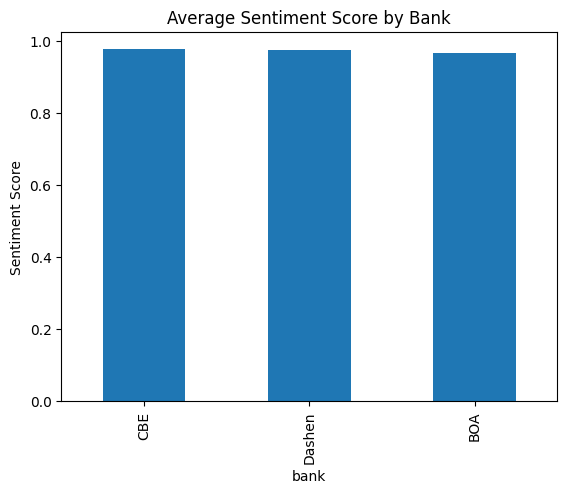

In [8]:
bank_sentiment.plot(kind="bar")

plt.title("Average Sentiment Score by Bank")
plt.ylabel("Sentiment Score")

plt.show()

In [ ]:
# This allows Jupyter Notebook to access src/ folder.
import sys
import os

sys.path.append(os.path.abspath("../src"))

# SECTION 2 — Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sentiment_analysis import classifier
from thematic_analysis import assign_theme
from nlp_pipeline import preprocess_text